## Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For training and splitting data
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## Acquire and Explore Data

In [43]:
# Import csv files

buyer_lead_df = pd.read_csv("Phirst_Buyer_Lead.csv") # Buyers' responses

soma1_df = pd.read_csv("SOMA1_Availability.csv") # Availability of houses in SOMA1
soma2_df = pd.read_csv("SOMA2_Availability.csv") # Avaiability of houses in SOMA2 
soma3_df = pd.read_csv("SOMA3_Availability.csv") # Avaiability of houses in SOMA3
vismin_df = pd.read_csv("VISMIN_Availability.csv") # Avaiability of houses in VISMIN

### Explore Buyer Responses Data

In [44]:
# See the first 5 rows of buyer data

buyer_lead_df.head()

,Timestamp,Date,"Principal Buyer Full Name (First M.I., Family)",Age,Income of Principal Buyer,Marital Status,No. of Family Members,Preferred Location,SOURCE OF LEAD,Source of Income,Employer,Preferred Pay Term,"Spouse Full Name (First M.I., Family)",Age of Spouse,Income of Spouse
0,01/05/2024 19:22,01/05/2024,Client 1,29,"PHP 125,500",Married,7,BATULAO,Facebook Ads,Locally Employed,bdo unibank,20-80 Pagibig Financing,Spouse of Client 1,30,"PHP 83,000"
1,01/06/2024 11:56,01/06/2024,Client 2,27,"PHP 61,000",Married,2,MAGALANG EAST,Facebook Ads,Self Employed/ Business Owner,independent contractor,20-80 Pagibig Financing,Spouse of Client 2,25,"PHP 42,500"
2,01/11/2024 20:54,01/11/2024,Client 3,42,"PHP 247,000",Single,N/a,GAPAN,Broker/Agent,OFW Land base,Aramco,20-80 Pagibig Financing,N/a,N/a,N/a
3,01/15/2024 14:35:29,01/15/2024,Client 4,47,"PHP 32,500",Single,NaN,LIPA,Facebook Ads,OFW Land base,pricewaterhousecoopers uae,20-80 Pagibig Financing,NaN,NaN,NaN
4,01/17/2024 17:33:44,01/17/2024,Client 5,27,"PHP 243,000",Married,2,TAYABAS,Facebook Ads,OFW Land base,Hyundai engineering,20-80 Pagibig Financing,Spouse of Client 5,28,"PHP 224,500"


In [45]:
# See how many rows and columns there are
print("Total number of rows and columns:", buyer_lead_df.shape)

# Check for missing values
print("\nMissing values:")
print(buyer_lead_df.isnull().sum()) 

# Check the information 
print("\nInformation: ")
print(buyer_lead_df.info())

Total number of rows and columns: (600, 15)

Missing values:
Timestamp                                           0
Date                                                0
Principal Buyer Full Name (First M.I., Family)      0
Age                                                 0
Income of Principal Buyer                           0
Marital Status                                      0
No. of Family Members                             174
Preferred Location                                  0
SOURCE OF LEAD                                      0
Source of Income                                    0
Employer                                            0
Preferred Pay Term                                  0
Spouse Full Name (First M.I., Family)             183
Age of Spouse                                     183
Income of Spouse                                  183
dtype: int64

Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 column

In [46]:
# Clean the data and keep only necessary ones
# Rows with null values for columns 'Age of Spouse' and 'Income of Spouse' will be kept since not all buyers have spouses

buyer_lead_df = buyer_lead_df.drop(columns=['Timestamp', 'Date', 'Principal Buyer Full Name (First M.I., Family)', 'Employer', 'Spouse Full Name (First M.I., Family)'])

buyer_lead_df # shows the updated data

,Age,Income of Principal Buyer,Marital Status,No. of Family Members,Preferred Location,SOURCE OF LEAD,Source of Income,Preferred Pay Term,Age of Spouse,Income of Spouse
0,29,"PHP 125,500",Married,7,BATULAO,Facebook Ads,Locally Employed,20-80 Pagibig Financing,30,"PHP 83,000"
1,27,"PHP 61,000",Married,2,MAGALANG EAST,Facebook Ads,Self Employed/ Business Owner,20-80 Pagibig Financing,25,"PHP 42,500"
2,42,"PHP 247,000",Single,N/a,GAPAN,Broker/Agent,OFW Land base,20-80 Pagibig Financing,N/a,N/a
3,47,"PHP 32,500",Single,NaN,LIPA,Facebook Ads,OFW Land base,20-80 Pagibig Financing,NaN,NaN
4,27,"PHP 243,000",Married,2,TAYABAS,Facebook Ads,OFW Land base,20-80 Pagibig Financing,28,"PHP 224,500"
...,...,...,...,...,...,...,...,...,...,...
595,37,"PHP 209,000",Single,N/a,BATULAO,Broker/Agent,OFW Land base,20-80 Pagibig Financing,N/a,N/a
596,52,"PHP 35,000",Married,7,GEN TRI,Facebook Ads,OFW Land base,20-80 Pagibig Financing,52,"PHP 28,000"
597,25,"PHP 65,500",Widow,NaN,BALIWAG,Broker/Agent,OFW Sea Base,20-80 Pagibig Financing,NaN,NaN
598,55,"PHP 113,000",Married,7,LIPA,Referral,OFW Land base,20-80 Pagibig Financing,60,"PHP 81,500"


### Explore SOMA1 Availability Data

In [47]:
# Check the first 5 rows of SOMA1 data
soma1_df.head()

,Unit Code,GEO,PROJECT,PHASE,SUB PHASE,BATCH,UNIT TYPE,LOT AREA,FLOOR AREA,TCP,VAT,TCP w/o VAT,ETD,S HOUSECON,SU & INVENTORY,APPLICABLE TERM,HOUSECON REMARKS,Unnamed: 17
0,B022L001,SOMA1,GEN TRI,3,B,1,UNNA CORNER,137,54,"6,145,947.00","614,597.87","5,531,349.13",Oct-27,0%,0%,OPEN,MEMO TERM,YELLOW TAG
1,B022L030,SOMA1,GEN TRI,3,B,1,UNNA CORNER,139,54,"6,031,025.00","603,109.87","5,427,915.13",Oct-27,0%,0%,OPEN,MEMO TERM,YELLOW TAG
2,B022L034,SOMA1,GEN TRI,3,B,1,UNNA CORNER,153,54,"6,352,645.00","635,265.55","5,717,379.45",Nov-27,0%,0%,OPEN,MEMO TERM,YELLOW TAG
3,B022L036,SOMA1,GEN TRI,3,B,1,UNNA CORNER,138,54,"6,008,088.00","600,813.03","5,407,274.97",Nov-27,0%,0%,OPEN,MEMO TERM,YELLOW TAG
4,B023L001,SOMA1,GEN TRI,3,B,1,UNNA CORNER,133,54,"5,926,361.00","480,000.01","5,446,360.99",Nov-27,17%,17%,OPEN,MEMO TERM,YELLOW TAG


In [48]:
# Check how many rows and columns the data has
print("Total number of rows and columns:", soma1_df.shape)

# Check for missing values
print("\nMissing values:")
print(soma1_df.isnull().sum())

# Check the information of all the data
print("\nInformation: ")
soma1_df.info()

Total number of rows and columns: (633, 18)

Missing values:
Unit Code             0
GEO                   0
PROJECT               0
PHASE                 0
SUB PHASE           293
BATCH                 0
UNIT TYPE             0
LOT AREA              0
FLOOR AREA            0
TCP                   0
VAT                   2
TCP w/o VAT           0
ETD                   0
S HOUSECON            0
SU & INVENTORY        0
APPLICABLE TERM       0
HOUSECON REMARKS      0
Unnamed: 17           0
dtype: int64

Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unit Code         633 non-null    object
 1   GEO               633 non-null    object
 2   PROJECT           633 non-null    object
 3   PHASE             633 non-null    int64 
 4   SUB PHASE         340 non-null    object
 5   BATCH             633 non-null    object
 6   U

In [49]:
# Clean the data and keep only necessary ones

soma1_df = soma1_df.drop(columns=['GEO', 'PHASE', 'SUB PHASE', 'BATCH', 'FLOOR AREA', 'VAT', 'ETD', 'S HOUSECON', 'SU & INVENTORY', 'APPLICABLE TERM', 'HOUSECON REMARKS', 'Unnamed: 17'])

soma1_df # shows the updated data

,Unit Code,PROJECT,UNIT TYPE,LOT AREA,TCP,TCP w/o VAT
0,B022L001,GEN TRI,UNNA CORNER,137,"6,145,947.00","5,531,349.13"
1,B022L030,GEN TRI,UNNA CORNER,139,"6,031,025.00","5,427,915.13"
2,B022L034,GEN TRI,UNNA CORNER,153,"6,352,645.00","5,717,379.45"
3,B022L036,GEN TRI,UNNA CORNER,138,"6,008,088.00","5,407,274.97"
4,B023L001,GEN TRI,UNNA CORNER,133,"5,926,361.00","5,446,360.99"
...,...,...,...,...,...,...
628,B009L007,BALIWAG EXPANSION,CALISTA END,66,"3,299,878.00","3,299,878.00"
629,B009L027,BALIWAG EXPANSION,CALISTA END,66,"3,299,878","3,299,878"
630,B029L007,GAPAN,CALISTA MID,44,"1,969,092","1,969,092"
631,B029L006,GAPAN,CALISTA MID,44,"1,969,092.00","1,969,092.00"


In [50]:
# Check for duplicate values
print("\nTotal duplicate units:", soma1_df[['Unit Code']].duplicated().sum())


Total duplicate units: 82


In [51]:
# Drop the duplicated Unit Code rows
soma1_df = soma1_df.drop_duplicates(subset = 'Unit Code', keep = 'last')

# Prints the updated information without duplicates
soma1_df.info() 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 551 entries, 1 to 632
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unit Code    551 non-null    object
 1   PROJECT      551 non-null    object
 2   UNIT TYPE    551 non-null    object
 3   LOT AREA     551 non-null    int64 
 4   TCP          551 non-null    object
 5   TCP w/o VAT  551 non-null    object
dtypes: int64(1), object(5)
memory usage: 30.1+ KB


### Explore SOMA2 Availability Data

In [52]:
# Check the first 5 rows of SOMA2 data
soma2_df.head()

,UNIT CODE,COM,GEO,PROJECT,PHASE,SUB PHASE,BATCH,UNIT TYPE,LOT AREA,FLOOR AREA,TCP,VAT,TCP w/o VAT,ESTIMATED TURNOVER DATE,S HOUSECON,SU & INVENTORY,APPLICABLE TERM,HOUSE CON TAG,Unnamed: 18,Unnamed: 19
0,B044L009,PPHI,SOMA2,TAYABAS,1.0,B,1,CALISTA MID,44,40.0,"1,813,157.71",0.00,"1,813,157.71",Aug-2025,100%,80%,OPEN,RSBS WITHIN THE MONTH,RED TAG,NaN
1,B044L011,PPHI,SOMA2,TAYABAS,1.0,B,1,CALISTA MID,44,40.0,"1,813,157.71",0.00,"1,813,157.71",Aug-2025,100%,80%,OPEN,RSBS WITHIN THE MONTH,RED TAG,NaN
2,B044L019,PPHI,SOMA2,TAYABAS,1.0,B,1,CALISTA MID,44,40.0,"1,813,157.71",0.00,"1,813,157.71",Aug-2025,100%,80%,OPEN,RSBS WITHIN THE MONTH,RED TAG,NaN
3,B044L021,PPHI,SOMA2,TAYABAS,1.0,B,1,CALISTA MID,44,40.0,"1,813,157.71",0.00,"1,813,157.71",Aug-2025,100%,80%,OPEN,RSBS WITHIN THE MONTH,RED TAG,NaN
4,B044L040,PPHI,SOMA2,TAYABAS,1.0,B,1,CALISTA MID,44,40.0,"1,789,537.65",0.00,"1,789,537.65",Aug-2025,100%,80%,OPEN,RSBS WITHIN THE MONTH,RED TAG,NaN


In [53]:
# Check how many rows and columns the data has
print("Total number of rows and columns:", soma2_df.shape)

# Check for missing values
print("\nMissing values:")
print(soma2_df.isnull().sum())

# Check the information of all the data
print("\nInformation: ")
soma2_df.info()

Total number of rows and columns: (3345, 20)

Missing values:
UNIT CODE                  1978
COM                        1978
GEO                        1978
PROJECT                    1978
PHASE                      1978
SUB PHASE                  2532
BATCH                      1992
UNIT TYPE                  1978
LOT AREA                   1978
FLOOR AREA                 1992
TCP                        1978
VAT                        2152
TCP w/o VAT                1978
ESTIMATED TURNOVER DATE    1978
S HOUSECON                 1978
SU & INVENTORY             1978
APPLICABLE TERM            1978
HOUSE CON TAG              1978
Unnamed: 18                1978
Unnamed: 19                3345
dtype: int64

Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3345 entries, 0 to 3344
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UNIT CODE                1367 non-null   object 
 

In [54]:
# Clean the data and keep only necessary ones

soma2_df = soma2_df.drop(columns=['COM', 'GEO', 'PHASE', 'SUB PHASE', 'BATCH', 'FLOOR AREA', 'VAT', 'ESTIMATED TURNOVER DATE', 'S HOUSECON', 'SU & INVENTORY', 'APPLICABLE TERM', 'HOUSE CON TAG', 'Unnamed: 18', 'Unnamed: 19'])

soma2_df # shows the updated data

,UNIT CODE,PROJECT,UNIT TYPE,LOT AREA,TCP,TCP w/o VAT
0,B044L009,TAYABAS,CALISTA MID,44,"1,813,157.71","1,813,157.71"
1,B044L011,TAYABAS,CALISTA MID,44,"1,813,157.71","1,813,157.71"
2,B044L019,TAYABAS,CALISTA MID,44,"1,813,157.71","1,813,157.71"
3,B044L021,TAYABAS,CALISTA MID,44,"1,813,157.71","1,813,157.71"
4,B044L040,TAYABAS,CALISTA MID,44,"1,789,537.65","1,789,537.65"
...,...,...,...,...,...,...
3340,NaN,NaN,NaN,NaN,NaN,NaN
3341,NaN,NaN,NaN,NaN,NaN,NaN
3342,NaN,NaN,NaN,NaN,NaN,NaN
3343,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
# Drop rows with null values

soma2_df = soma2_df.dropna()
soma2_df.shape # shows how many rows there are with no null values

(1367, 6)

In [56]:
# Check for duplicate values
print("\nTotal duplicate units:", soma2_df[['UNIT CODE']].duplicated().sum())


Total duplicate units: 145


In [57]:
# Drop the duplicated Unit Code rows
soma2_df = soma2_df.drop_duplicates(subset = 'UNIT CODE', keep = 'last')

# Prints the updated information without duplicates
soma2_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1222 entries, 0 to 1366
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   UNIT CODE    1222 non-null   object
 1   PROJECT      1222 non-null   object
 2   UNIT TYPE    1222 non-null   object
 3   LOT AREA     1222 non-null   object
 4   TCP          1222 non-null   object
 5   TCP w/o VAT  1222 non-null   object
dtypes: object(6)
memory usage: 66.8+ KB


### Explore SOMA3 Availability Data

In [58]:
# Check the first 5 rows of SOMA1 data
soma3_df.head()

,UNIT CODE,GEO,PROJECT,PHASE,SUB PHASE,BATCH,UNIT TYPE,LOT AREA,FLOOR AREA,TCP,VAT,TCP w/o VAT,ESTIMATED TURNOVER DATE,S HOUSECON,SU & INVENTORY,APPLICABLE TERM,HOUSE CON TAG,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,B041L065,SOMA3,LIPA,1.0,A,1,CALISTA MID,44.0,40.0,"1,999,907.00",0.00,"1,999,907.00",Dec-2026,80%,REOPEN,RSBS WITHIN THE MONTH,RED TAG,NaN,NaN,NaN
1,B042L047,SOMA3,LIPA,1.0,A,2,CALISTA MID,44.0,40.0,"1,999,907.00",0,"1,999,907.00",Dec-2026,80%,REOPEN,RSBS WITHIN THE MONTH,RED TAG,NaN,NaN,NaN
2,B042L043,SOMA3,LIPA,1.0,A,2,CALISTA MID,44.0,40.0,"1,999,907.00",0,"1,999,907.00",Dec-2026,80%,REOPEN,RSBS WITHIN THE MONTH,RED TAG,NaN,NaN,NaN
3,B032L020,SOMA3,BATULAO,1.0,A,3,CALISTA END,147.0,40.0,"5,824,953.00","582,499","5,242,455.00",May-2025,80%,REOPEN,RSBS WITHIN THE MONTH,RED TAG,NaN,NaN,NaN
4,B004L003,SOMA3,EDITIONS BATULAO VOL. 1,2.0,NaN,1,CORIN,188.0,120.0,"10,837,123.00","1,083,720","9,753,403.00",Feb-2026,60%,OPEN,MEMO TERMS,RED TAG,NaN,NaN,NaN


In [59]:
# Check how many rows and columns the data has
print("Total number of rows and columns:", soma3_df.shape)

# Check for missing values
print("\nMissing values:")
print(soma3_df.isnull().sum())

# Check the information of all the data
print("\nInformation: ")
soma3_df.info()

Total number of rows and columns: (802, 20)

Missing values:
UNIT CODE                   19
GEO                         19
PROJECT                     19
PHASE                       19
SUB PHASE                  418
BATCH                       61
UNIT TYPE                   19
LOT AREA                    19
FLOOR AREA                  33
TCP                         19
VAT                        456
TCP w/o VAT                 19
ESTIMATED TURNOVER DATE     61
S HOUSECON                  18
SU & INVENTORY              19
APPLICABLE TERM             19
HOUSE CON TAG               19
Unnamed: 17                802
Unnamed: 18                802
Unnamed: 19                802
dtype: int64

Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UNIT CODE                783 non-null    object 
 1   GEO                

In [60]:
# Clean the data and keep only necessary ones

soma3_df = soma3_df.drop(columns=['GEO', 'PHASE', 'SUB PHASE', 'BATCH', 'FLOOR AREA', 'VAT', 'ESTIMATED TURNOVER DATE', 'S HOUSECON', 'SU & INVENTORY', 'APPLICABLE TERM', 'HOUSE CON TAG', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19'])

soma3_df # shows the updated data

,UNIT CODE,PROJECT,UNIT TYPE,LOT AREA,TCP,TCP w/o VAT
0,B041L065,LIPA,CALISTA MID,44.0,"1,999,907.00","1,999,907.00"
1,B042L047,LIPA,CALISTA MID,44.0,"1,999,907.00","1,999,907.00"
2,B042L043,LIPA,CALISTA MID,44.0,"1,999,907.00","1,999,907.00"
3,B032L020,BATULAO,CALISTA END,147.0,"5,824,953.00","5,242,455.00"
4,B004L003,EDITIONS BATULAO VOL. 1,CORIN,188.0,"10,837,123.00","9,753,403.00"
...,...,...,...,...,...,...
797,NaN,NaN,NaN,NaN,NaN,NaN
798,NaN,NaN,NaN,NaN,NaN,NaN
799,NaN,NaN,NaN,NaN,NaN,NaN
800,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
# Drop rows with null values

soma3_df = soma3_df.dropna()
soma3_df.shape # shows how many rows there are with no null values

(783, 6)

In [62]:
# Check for duplicate values
print("\nTotal duplicate units:", soma3_df[['UNIT CODE']].duplicated().sum())


Total duplicate units: 52


In [63]:
# Drop the duplicated Unit Code rows
soma3_df = soma3_df.drop_duplicates(subset = 'UNIT CODE', keep = 'last')

# Prints the updated information without duplicates
soma3_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 731 entries, 0 to 782
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UNIT CODE    731 non-null    object 
 1   PROJECT      731 non-null    object 
 2   UNIT TYPE    731 non-null    object 
 3   LOT AREA     731 non-null    float64
 4   TCP          731 non-null    object 
 5   TCP w/o VAT  731 non-null    object 
dtypes: float64(1), object(5)
memory usage: 40.0+ KB


### Explore VISMIN Availability Data

In [64]:
# Check the first 5 rows of SOMA1 data
vismin_df.head()

,UNIT CODE,GEO,PROJECT,PHASE,SUB PHASE,BATCH,UNIT TYPE,LOT AREA,FLOOR AREA,TCP,...,TCP w/o VAT,ESTIMATED TURNOVER,HOUSE CON,INVENTORY STATUS,HOLDING STATUS,HOUSE TAGGING,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20
0,B024L044,VISMIN,BACOLOD,1.0,A,2.0,AMANI END,157.0,36.0,"3,359,781.43",...,"3,359,781.43",Jan-2026,100%,REOPEN,RSBS WITHI THIS MONTH,RED TAGGING,NaN,NaN,NaN,NaN
1,B030L002,VISMIN,BACOLOD,1.0,A,5.0,AMANI END,161.0,36.0,"3,593,445.34",...,"3,593,445.34",Oct-2026,0%,OPEN,MEMO TERMS,YELLOW TAGGING,NaN,NaN,NaN,NaN
2,B032L008,VISMIN,BACOLOD,1.0,A,5.0,AMANI END,142.0,36.0,"3,328,360.61",...,"3,328,360.61",Dec-2026,12%,OPEN,MEMO TERMS,YELLOW TAGGING,NaN,NaN,NaN,NaN
3,B033L001,VISMIN,BACOLOD,1.0,A,5.0,AMANI END CORNER,210.0,36.0,"4,371,998.44",...,"4,371,998.44",Dec-2026,0%,OPEN,MEMO TERMS,YELLOW TAGGING,NaN,NaN,NaN,NaN
4,B033L002,VISMIN,BACOLOD,1.0,A,5.0,AMANI END,153.0,36.0,"3,450,822.75",...,"3,450,822.75",Dec-2026,0%,OPEN,MEMO TERMS,YELLOW TAGGING,NaN,NaN,NaN,NaN


In [65]:
# Check how many rows and columns the data has
print("Total number of rows and columns:", vismin_df.shape)

# Check for missing values
print("\nMissing values:")
print(vismin_df.isnull().sum())

# Check the information of all the data
print("\nInformation: ")
vismin_df.info()

Total number of rows and columns: (1120, 21)

Missing values:
UNIT CODE              720
GEO                    720
PROJECT                720
PHASE                  720
SUB PHASE             1004
BATCH                  720
UNIT TYPE              720
LOT AREA               720
FLOOR AREA             720
TCP                    720
VAT                    932
TCP w/o VAT            720
ESTIMATED TURNOVER     848
HOUSE CON              720
INVENTORY STATUS       720
HOLDING STATUS         720
HOUSE TAGGING          720
Unnamed: 17           1120
Unnamed: 18           1120
Unnamed: 19           1120
Unnamed: 20           1120
dtype: int64

Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1120 entries, 0 to 1119
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   UNIT CODE           400 non-null    object 
 1   GEO                 400 non-null    object 
 2   PROJECT             400 non-null   

In [66]:
# Clean the data and keep only necessary ones

vismin_df = vismin_df.drop(columns=['GEO', 'PHASE', 'SUB PHASE', 'BATCH', 'FLOOR AREA', 'VAT', 'ESTIMATED TURNOVER', 'HOUSE CON', 'INVENTORY STATUS', 'HOLDING STATUS', 'HOUSE TAGGING', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20'])

vismin_df # shows the updated data

,UNIT CODE,PROJECT,UNIT TYPE,LOT AREA,TCP,TCP w/o VAT
0,B024L044,BACOLOD,AMANI END,157.0,"3,359,781.43","3,359,781.43"
1,B030L002,BACOLOD,AMANI END,161.0,"3,593,445.34","3,593,445.34"
2,B032L008,BACOLOD,AMANI END,142.0,"3,328,360.61","3,328,360.61"
3,B033L001,BACOLOD,AMANI END CORNER,210.0,"4,371,998.44","4,371,998.44"
4,B033L002,BACOLOD,AMANI END,153.0,"3,450,822.75","3,450,822.75"
...,...,...,...,...,...,...
1115,NaN,NaN,NaN,NaN,NaN,NaN
1116,NaN,NaN,NaN,NaN,NaN,NaN
1117,NaN,NaN,NaN,NaN,NaN,NaN
1118,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
# Drop rows with null values

vismin_df = vismin_df.dropna()
vismin_df.shape # shows how many rows there are with no null values

(400, 6)

In [68]:
# Check for duplicate values
print("\nTotal duplicate units:", vismin_df[['UNIT CODE']].duplicated().sum())


Total duplicate units: 24


In [69]:
# Drop the duplicated Unit Code rows
vismin_df = vismin_df.drop_duplicates(subset = 'UNIT CODE', keep = 'last')

# Prints the updated information without duplicates
vismin_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 376 entries, 0 to 399
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UNIT CODE    376 non-null    object 
 1   PROJECT      376 non-null    object 
 2   UNIT TYPE    376 non-null    object 
 3   LOT AREA     376 non-null    float64
 4   TCP          376 non-null    object 
 5   TCP w/o VAT  376 non-null    object 
dtypes: float64(1), object(5)
memory usage: 20.6+ KB


## Exploratory Data Analysis (EDA)

Now that the data has been loaded and cleaned, we will explore the datasets more deeply.  
The goal is to understand the distribution of buyer demographics, income levels, preferences, and housing availability across different locations.  
This section uses visualizations and summary statistics to uncover patterns and insights.

### 3.1 Buyer Demographics

We start by analyzing who the buyers are — their age, marital status, income, and number of family members.  
This helps us understand the typical profile of a Phirst Park Homes buyer.

In [70]:
# Convert income to numeric for analysis
buyer_lead_df['Income_Numeric'] = (
    buyer_lead_df['Income of Principal Buyer']
    .astype(str)
    .str.replace('PHP', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
)

# Create age groups
bins = [24, 30, 40, 50, 56]
labels = ['25–30', '31–40', '41–50', '51–55']
buyer_lead_df['Age Group'] = pd.cut(buyer_lead_df['Age'], bins=bins, labels=labels)

print("Age Group Distribution:")
print(buyer_lead_df['Age Group'].value_counts().sort_index())
print()
print("Marital Status Distribution:")
print(buyer_lead_df['Marital Status'].value_counts())
print()
print("Income Summary (PHP):")
print(buyer_lead_df['Income_Numeric'].describe().apply(lambda x: f'{x:,.2f}'))


Age Group Distribution:
25–30    115
31–40    210
41–50    191
51–55     84
Name: Age Group, dtype: int64

Marital Status Distribution:
Married    330
Single     219
Widow       51
Name: Marital Status, dtype: int64

Income Summary (PHP):
count        600.00
mean     116,093.33
std       65,972.78
min       16,000.00
25%       58,500.00
50%      112,750.00
75%      166,500.00
max      292,500.00
Name: Income_Numeric, dtype: object


The chart below shows the age distribution of buyers and their marital status side by side.  
Most buyers fall in the **31–40** age bracket, and the majority are **married**.

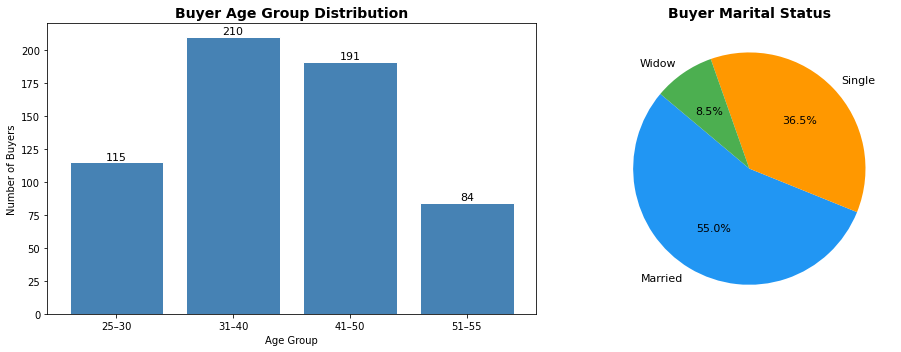

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Group Distribution
age_counts = buyer_lead_df['Age Group'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Buyer Age Group Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Buyers')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=11)

# Marital Status
marital_counts = buyer_lead_df['Marital Status'].value_counts()
colors = ['#2196F3', '#FF9800', '#4CAF50']
axes[1].pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Buyer Marital Status', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### 3.2 Income Distribution

Understanding buyer income helps determine affordability and which housing products are suitable for different segments.  
The histogram below shows the spread of monthly income among principal buyers.

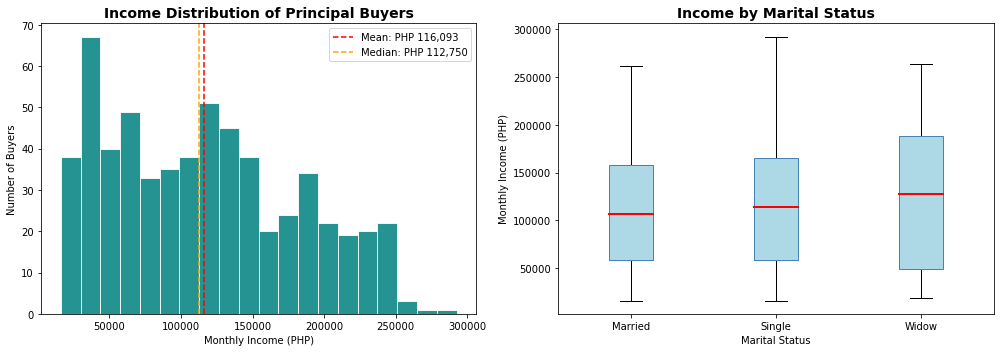

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income Histogram
axes[0].hist(buyer_lead_df['Income_Numeric'].dropna(), bins=20, color='teal', edgecolor='white', alpha=0.85)
axes[0].axvline(buyer_lead_df['Income_Numeric'].mean(), color='red', linestyle='--', label=f"Mean: PHP {buyer_lead_df['Income_Numeric'].mean():,.0f}")
axes[0].axvline(buyer_lead_df['Income_Numeric'].median(), color='orange', linestyle='--', label=f"Median: PHP {buyer_lead_df['Income_Numeric'].median():,.0f}")
axes[0].set_title('Income Distribution of Principal Buyers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monthly Income (PHP)')
axes[0].set_ylabel('Number of Buyers')
axes[0].legend()

# Income by Marital Status (Boxplot)
married = buyer_lead_df[buyer_lead_df['Marital Status'] == 'Married']['Income_Numeric'].dropna()
single  = buyer_lead_df[buyer_lead_df['Marital Status'] == 'Single']['Income_Numeric'].dropna()
widow   = buyer_lead_df[buyer_lead_df['Marital Status'] == 'Widow']['Income_Numeric'].dropna()

axes[1].boxplot([married, single, widow], labels=['Married', 'Single', 'Widow'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Income by Marital Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Monthly Income (PHP)')

plt.tight_layout()
plt.show()


### 3.3 Lead Sources and Source of Income

This section shows how buyers found out about Phirst Park Homes and what their primary source of income is.  
These insights are useful for marketing strategy and understanding the buyer profile.

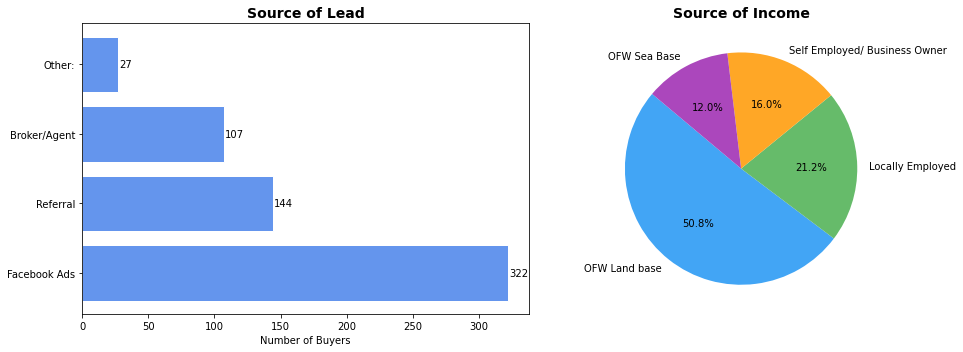

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source of Lead
lead_counts = buyer_lead_df['SOURCE OF LEAD'].value_counts()
axes[0].barh(lead_counts.index, lead_counts.values, color='cornflowerblue', edgecolor='white')
axes[0].set_title('Source of Lead', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Buyers')
for i, v in enumerate(lead_counts.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=10)

# Source of Income
income_src_counts = buyer_lead_df['Source of Income'].value_counts()
colors = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']
axes[1].pie(income_src_counts, labels=income_src_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Source of Income', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


**Key Observations:**
- **Facebook Ads** is the dominant lead source (~53.7%), showing the importance of digital marketing.
- **Referrals** and **Broker/Agents** are also significant, highlighting the value of word-of-mouth and agent networks.
- The majority of buyers are **OFW Land-based** workers, followed by locally employed individuals.

### 3.4 Preferred Location

Buyers were asked to indicate their preferred location. This reveals which Phirst Park Homes communities are most in demand.

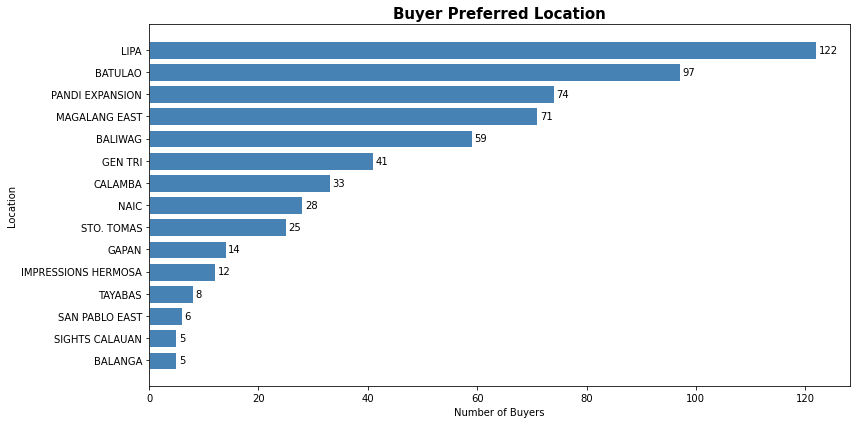

In [74]:
location_counts = buyer_lead_df['Preferred Location'].value_counts()

plt.figure(figsize=(12, 6))
bars = plt.barh(location_counts.index[::-1], location_counts.values[::-1], color='steelblue', edgecolor='white')
plt.title('Buyer Preferred Location', fontsize=15, fontweight='bold')
plt.xlabel('Number of Buyers')
plt.ylabel('Location')
for bar, val in zip(bars, location_counts.values[::-1]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.show()


### 3.5 Preferred Payment Term

Understanding how buyers want to pay helps tailor financing packages and partnerships with banks or Pag-IBIG.

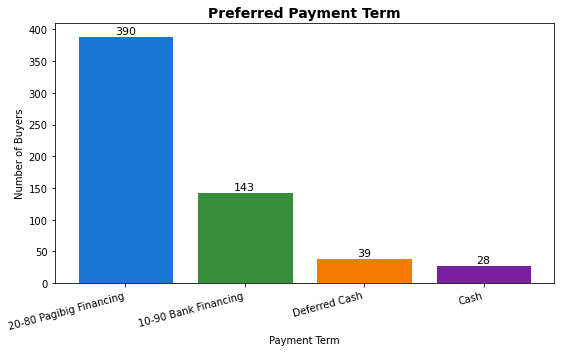

In [75]:
pay_counts = buyer_lead_df['Preferred Pay Term'].value_counts()
colors = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

plt.figure(figsize=(8, 5))
bars = plt.bar(pay_counts.index, pay_counts.values, color=colors, edgecolor='white')
plt.title('Preferred Payment Term', fontsize=14, fontweight='bold')
plt.xlabel('Payment Term')
plt.ylabel('Number of Buyers')
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, pay_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


**Key Finding:** The vast majority of buyers (65%) prefer **20-80 Pag-IBIG Financing**, consistent with the OFW/employed buyer profile that qualifies for government-backed housing loans.

### 3.6 Family Size

The number of family members is an important factor in housing demand — larger families tend to prefer bigger unit types.

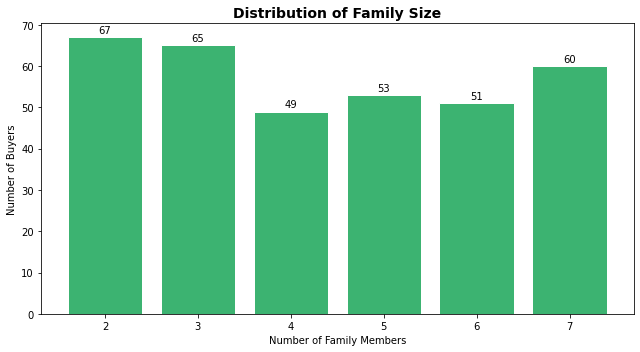

Average family size: 4.39
Most common family size: 2


In [76]:
family_col = pd.to_numeric(buyer_lead_df['No. of Family Members'], errors='coerce')
family_counts = family_col.value_counts().sort_index().dropna()

plt.figure(figsize=(9, 5))
plt.bar(family_counts.index.astype(int).astype(str), family_counts.values, color='mediumseagreen', edgecolor='white')
plt.title('Distribution of Family Size', fontsize=14, fontweight='bold')
plt.xlabel('Number of Family Members')
plt.ylabel('Number of Buyers')
for i, (idx, val) in enumerate(zip(family_counts.index, family_counts.values)):
    plt.text(i, val + 1, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Average family size: {family_col.mean():.2f}")
print(f"Most common family size: {int(family_col.mode()[0])}")


---
### 3.7 Housing Availability Analysis

We now look at the four availability datasets — **SOMA1, SOMA2, SOMA3, and VISMIN** — to understand the supply side: how many units are available per project and what unit types are offered.

In [77]:
# Standardize column names across all availability dataframes
soma1_df.columns = [c.upper() for c in soma1_df.columns]
soma1_df = soma1_df.rename(columns={'TCP W/O VAT': 'TCP_NO_VAT'})

soma2_df.columns = [c.upper() for c in soma2_df.columns]
soma2_df = soma2_df.rename(columns={'TCP W/O VAT': 'TCP_NO_VAT'})

soma3_df.columns = [c.upper() for c in soma3_df.columns]
soma3_df = soma3_df.rename(columns={'TCP W/O VAT': 'TCP_NO_VAT'})

vismin_df.columns = [c.upper() for c in vismin_df.columns]
vismin_df = vismin_df.rename(columns={'TCP W/O VAT': 'TCP_NO_VAT'})

# Tag each with region
soma1_df['REGION'] = 'SOMA1'
soma2_df['REGION'] = 'SOMA2'
soma3_df['REGION'] = 'SOMA3'
vismin_df['REGION'] = 'VISMIN'

# Combine into one dataframe
all_avail = pd.concat([soma1_df, soma2_df, soma3_df, vismin_df], ignore_index=True)

# Clean TCP to numeric
all_avail['TCP_NUM'] = (
    all_avail['TCP']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('PHP', '', regex=False)
    .str.strip()
    .pipe(pd.to_numeric, errors='coerce')
)

# Clean LOT AREA to numeric
all_avail['LOT_AREA_NUM'] = pd.to_numeric(all_avail['LOT AREA'], errors='coerce')

print("Total units across all regions:", len(all_avail))
print()
print("Units per region:")
print(all_avail['REGION'].value_counts())


Total units across all regions: 2880

Units per region:
SOMA2     1222
SOMA3      731
SOMA1      551
VISMIN     376
Name: REGION, dtype: int64


The chart below shows the total number of available housing units per region.  
**SOMA2** has the largest inventory, while **VISMIN** has the fewest units available.

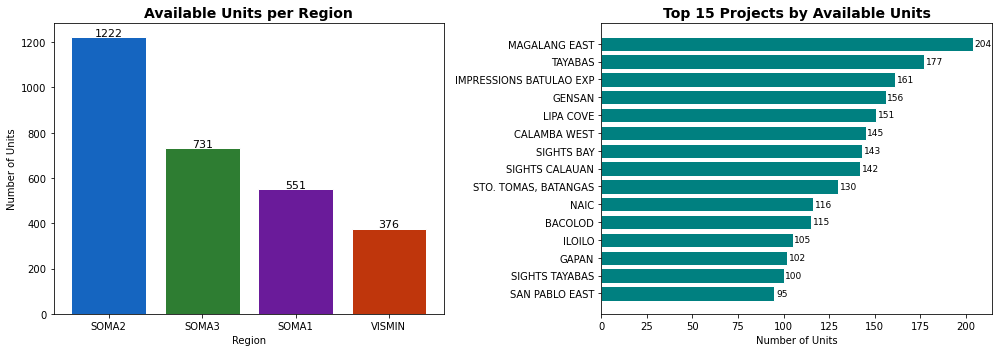

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Units per region
region_counts = all_avail['REGION'].value_counts()
colors_region = ['#1565C0', '#2E7D32', '#6A1B9A', '#BF360C']
axes[0].bar(region_counts.index, region_counts.values, color=colors_region, edgecolor='white')
axes[0].set_title('Available Units per Region', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Number of Units')
for i, v in enumerate(region_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Units per project (top 15)
project_counts = all_avail['PROJECT'].value_counts().head(15)
axes[1].barh(project_counts.index[::-1], project_counts.values[::-1], color='teal', edgecolor='white')
axes[1].set_title('Top 15 Projects by Available Units', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Units')
for i, v in enumerate(project_counts.values[::-1]):
    axes[1].text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 3.8 Unit Type Distribution

Different unit types cater to different buyer segments. The Calista series is the entry-level product, while Amani, Alora, and larger types target move-up buyers.

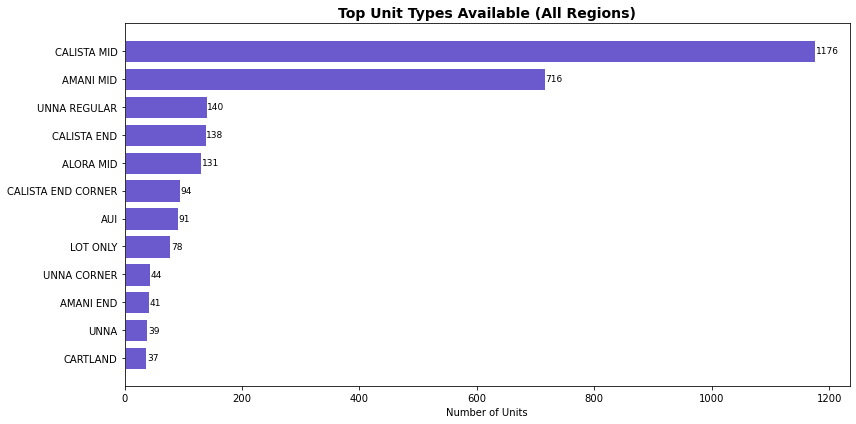

In [79]:
# Standardize unit type casing
all_avail['UNIT TYPE CLEAN'] = all_avail['UNIT TYPE'].str.upper().str.strip()
unit_counts = all_avail['UNIT TYPE CLEAN'].value_counts().head(12)

plt.figure(figsize=(12, 6))
bars = plt.barh(unit_counts.index[::-1], unit_counts.values[::-1], color='slateblue', edgecolor='white')
plt.title('Top Unit Types Available (All Regions)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Units')
for bar, val in zip(bars, unit_counts.values[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()


### 3.9 Total Contract Price (TCP) Distribution

The TCP is the selling price of each unit. Analyzing this helps us understand pricing tiers and map them against buyer income capacity.

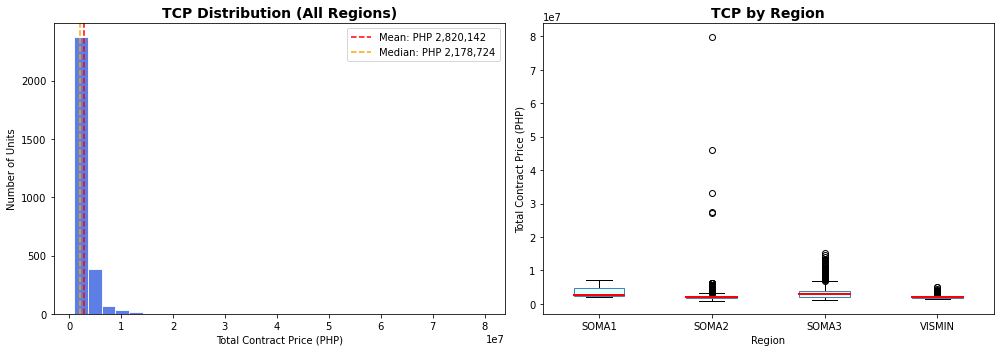

TCP Summary Statistics (PHP):
                 mean            min         median             max
REGION                                                             
SOMA1   PHP 3,308,914  PHP 1,940,047  PHP 2,570,855   PHP 7,276,960
SOMA2   PHP 2,324,160    PHP 980,000  PHP 1,909,801  PHP 79,898,389
SOMA3   PHP 3,656,625  PHP 1,302,428  PHP 2,952,631  PHP 15,140,491
VISMIN  PHP 2,089,572  PHP 1,549,000  PHP 1,940,467   PHP 5,032,315


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TCP histogram overall
axes[0].hist(all_avail['TCP_NUM'].dropna(), bins=30, color='royalblue', edgecolor='white', alpha=0.85)
axes[0].axvline(all_avail['TCP_NUM'].mean(), color='red', linestyle='--',
                label=f"Mean: PHP {all_avail['TCP_NUM'].mean():,.0f}")
axes[0].axvline(all_avail['TCP_NUM'].median(), color='orange', linestyle='--',
                label=f"Median: PHP {all_avail['TCP_NUM'].median():,.0f}")
axes[0].set_title('TCP Distribution (All Regions)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Contract Price (PHP)')
axes[0].set_ylabel('Number of Units')
axes[0].legend()

# TCP by Region (Boxplot)
tcp_by_region = [all_avail[all_avail['REGION']==r]['TCP_NUM'].dropna() for r in ['SOMA1','SOMA2','SOMA3','VISMIN']]
axes[1].boxplot(tcp_by_region, labels=['SOMA1','SOMA2','SOMA3','VISMIN'], patch_artist=True,
                boxprops=dict(facecolor='lightcyan', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('TCP by Region', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Contract Price (PHP)')

plt.tight_layout()
plt.show()

print("TCP Summary Statistics (PHP):")
tcp_summary = all_avail.groupby('REGION')['TCP_NUM'].agg(['mean','min','median','max'])
tcp_summary = tcp_summary.apply(lambda col: col.map(lambda x: f'PHP {x:,.0f}' if pd.notna(x) else 'N/A'))
print(tcp_summary)

**Key Observations:**
- **SOMA3** has the highest median TCP, likely due to premium projects like Batulao and Lipa Cove.
- **VISMIN** and **SOMA2** tend to have lower price points, making them more accessible to OFW and employed buyers.
- The TCP range spans roughly PHP 1.4M to PHP 4M+ across all regions.

### 3.10 Lot Area vs. Total Contract Price

We examine whether a larger lot area corresponds to a higher price — an expected relationship in real estate.

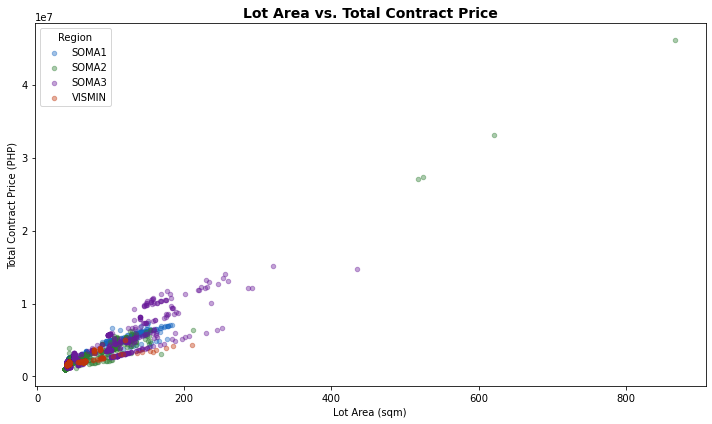

Pearson correlation between Lot Area and TCP: 0.9221


In [81]:
plt.figure(figsize=(10, 6))

region_colors = {'SOMA1': '#1565C0', 'SOMA2': '#2E7D32', 'SOMA3': '#6A1B9A', 'VISMIN': '#BF360C'}

for region, color in region_colors.items():
    subset = all_avail[all_avail['REGION'] == region]
    plt.scatter(subset['LOT_AREA_NUM'], subset['TCP_NUM'], alpha=0.4, s=20, color=color, label=region)

plt.title('Lot Area vs. Total Contract Price', fontsize=14, fontweight='bold')
plt.xlabel('Lot Area (sqm)')
plt.ylabel('Total Contract Price (PHP)')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

# Correlation
corr = all_avail[['LOT_AREA_NUM','TCP_NUM']].corr().iloc[0,1]
print(f"Pearson correlation between Lot Area and TCP: {corr:.4f}")


### 3.11 Demand vs. Supply: Buyer Preferences vs. Available Locations

This section compares where buyers want to buy (demand) against which locations have available inventory (supply).  
This is critical for identifying oversupply or undersupply in specific markets.

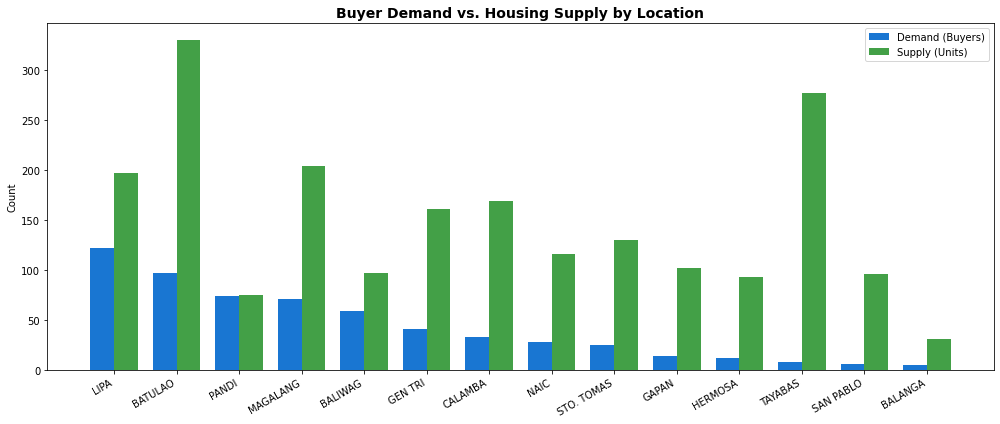

In [82]:
# Standardize location/project names for comparison
demand = buyer_lead_df['Preferred Location'].str.upper().str.strip().value_counts()
supply = all_avail['PROJECT'].str.upper().str.strip().value_counts()

# Overlap on shared keywords
common_keys = ['LIPA', 'BATULAO', 'PANDI', 'MAGALANG', 'BALIWAG', 'GEN TRI', 'CALAMBA',
               'NAIC', 'STO. TOMAS', 'GAPAN', 'HERMOSA', 'TAYABAS', 'SAN PABLO', 'BALANGA']

demand_agg = {}
supply_agg = {}

for key in common_keys:
    d_val = demand[demand.index.str.contains(key)].sum()
    s_val = supply[supply.index.str.contains(key)].sum()
    if d_val > 0 or s_val > 0:
        demand_agg[key] = d_val
        supply_agg[key] = s_val

ds_df = pd.DataFrame({'Demand (Buyers)': demand_agg, 'Supply (Units)': supply_agg}).fillna(0)
ds_df = ds_df.sort_values('Demand (Buyers)', ascending=False)

x = range(len(ds_df))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar([i - width/2 for i in x], ds_df['Demand (Buyers)'], width, label='Demand (Buyers)', color='#1976D2')
bars2 = ax.bar([i + width/2 for i in x], ds_df['Supply (Units)'], width, label='Supply (Units)', color='#43A047')
ax.set_xticks(list(x))
ax.set_xticklabels(ds_df.index, rotation=30, ha='right')
ax.set_title('Buyer Demand vs. Housing Supply by Location', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


**Supply-Demand Insights:**
- **LIPA** and **BATULAO** show relatively high buyer demand; supply in those areas should be watched closely.
- **MAGALANG** and **TAYABAS** have large supply but moderate demand, indicating potential promotional opportunities.
- Matching buyers to the right locations is key for sales conversion.

---
## Summary of EDA Findings

| Insight | Detail |
|---|---|
| **Typical buyer** | Married, 31–40 years old, OFW Land-based |
| **Avg. monthly income** | ~PHP 116,000 |
| **Top lead source** | Facebook Ads (53.7%) |
| **Top preferred location** | LIPA (20.3%) |
| **Preferred payment** | 20-80 Pag-IBIG Financing (65%) |
| **Largest inventory region** | SOMA2 (1,222 units) |
| **Most popular unit type** | Calista Mid |
| **TCP range** | PHP ~1.4M to PHP ~4M+ |
| **Lot area vs TCP** | Moderate positive correlation |

These findings will serve as the foundation for the predictive modeling phase.